# **Regression Models with Keras**

Keras is a high-level API for building deep learning models. It has gained favor for its ease of use and syntactic simplicity facilitating fast development. For people who are just starting to learn deep learning, there is no better library to use other than the keras library.


In this lab, you will learn how to use the Keras library to build a regression model.

<a id="item1"></a>

### **Download and Clean Dataset**

Let's start by importing the <em>pandas</em> and the Numpy library.

In [ ]:
import pandas as pd
import numpy as np

The dataset is about the compressive strength of different samples of concrete based on the volumes of the different materials that were used to make them. Ingredients include:

1. Cement

2. Blast Furnace Slag

3. Fly Ash

4. Water

5. Superplasticizer

6. Coarse Aggregate

7. Fine Aggregat

Let's download the data and read it into a <em>pandas</em> dataframe.

In [ ]:
concrete_data = pd.read_csv('https://ibm.box.com/shared/static/svl8tu7cmod6tizo6rk0ke4sbuhtpdfx.csv')
concrete_data.head(10)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29


So the first concrete sample has 540 cubic meter of cement, 0 cubic meter of blast furnace slag, 0 cubic meter of fly ash, 162 cubic meter of water, 2.5 cubic meter of superplasticizer, 1040 cubic meter of coarse aggregate, 676 cubic meter of fine aggregate. Such a concrete mix which is 28 days old, has a compressive strength of 79.99 MPa.

#### Let's check how many data points we have.

In [ ]:
concrete_data.shape

(1030, 9)

So, there are approximately 1000 samples to train our model on. Because of the  few samples, we have to be careful not to overfil the training data.

Let's print some descriptive statistics:

In [ ]:
concrete_data.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


Let's check the dataset for any missing values:

In [ ]:
concrete_data.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

The data looks very clean and is ready to be used to build our model.

Split data into predictors and target:

In [ ]:
concrete_data_columns = concrete_data.columns
print(concrete_data_columns, concrete_data_columns.dtype)

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object') object


In [ ]:
features = concrete_data[concrete_data_columns[concrete_data_columns != 'Strength']] # all columns except Strength
target = concrete_data['Strength'] # Strength column

In [ ]:
# of course, the split can also be done manually:
var_indep = concrete_data[['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age']]
var_indep.shape
var_indep.head()


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


Let's do a quick sanity check of the predictors and the target

In [ ]:
features.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [ ]:
target.head()

0    79.99
1    61.89
2    40.27
3    41.05
4    44.30
Name: Strength, dtype: float64

Finally, the last step is to normalize the data by substracting the mean and dividing by the standard deviation.

In [ ]:
# remember that in pandas dataframes, operators typically are applied on a by-column basis:
features.mean()

Cement                281.167864
Blast Furnace Slag     73.895825
Fly Ash                54.188350
Water                 181.567282
Superplasticizer        6.204660
Coarse Aggregate      972.918932
Fine Aggregate        773.580485
Age                    45.662136
dtype: float64

In [ ]:
features_norm = (features - features.mean()) / features.std()
features_norm.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,2.476712,-0.856472,-0.846733,-0.916319,-0.620147,0.862735,-1.217079,-0.279597
1,2.476712,-0.856472,-0.846733,-0.916319,-0.620147,1.055651,-1.217079,-0.279597
2,0.491187,0.795140,-0.846733,2.174405,-1.038638,-0.526262,-2.239829,3.551340
3,0.491187,0.795140,-0.846733,2.174405,-1.038638,-0.526262,-2.239829,5.055221
4,-0.790075,0.678079,-0.846733,0.488555,-1.038638,0.070492,0.647569,4.976069


In [ ]:
from sklearn.preprocessing import StandardScaler
features_norm = StandardScaler().fit_transform(features)
features_norm = pd.DataFrame(features_norm)
features_norm.head()

,0,1,2,3,4,5,6,7
0,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,0.863154,-1.217670,-0.279733
1,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,1.056164,-1.217670,-0.279733
2,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,3.553066
3,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,5.057677
4,-0.790459,0.678408,-0.847144,0.488793,-1.039143,0.070527,0.647884,4.978487


In [ ]:
print(features_norm.shape)
n_cols = features_norm.shape[1] # number of predictors
print(n_cols)


(1030, 8)
8


## **Import Keras. Discouraged, outdated**

Keras normally runs on top of a low-level library such as TensorFlow. This means that to be able to use the Keras library, you will have to install TensorFlow first and when you import keras, it will be explicitly displayed what backend was used to install the Keras library.

#### Let's go ahead and import the Keras library

In [ ]:
import keras

As you can see, the TensorFlow backend was used to install the Keras library.

## **Updating to Tensorflow 2.x.x**

In january 2020, **Tensorflow 2.0.0** was released. This and followings versions **integrate the keras library under `tensorflow.keras`**.

Of course, this `tensorflow.keras` version will just support the tensorflow backend, however, it will be the only version that will be maintained and updated in the future. The standalone keras version, with support for several neural network backends will not be mantained nor uptated anymore.

Therefore, **using the standalone keras version is discouraged**.




`tensorflow.keras` includes two different APIs:

- the **Sequential Model API** is for simple 'sequencial' models, that is basically stacked layers with direct conections just from one layer to the following, and without complex connections or feedbacks between layers.

- the **Functional Model API**, for much more complex models with any arbitrary design and connecting pattern.

For a quick tutorial on new tensorflow.keras library and general deep learning modeling approach, check https://machinelearningmastery.com/tensorflow-tutorial-deep-learning-with-tf-keras/.

In this quick tutorial, we will use just the simple sequential API.


The correct way of importing keras is now:

In [ ]:
import tensorflow.keras

Check the tensorflow and keras versions installed:

In [ ]:
tensorflow.__version__

'2.8.0'

In [ ]:
tensorflow.keras.__version__

'2.8.0'

Let's import the rest of the packages from the Keras library that we will need to build our regresion model.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## **Build Neural Network**

Let's define a function that defines our regression model for us so that we can conveniently call it to create our model.

Keras allows you to list the metrics to monitor during the training of your model.

Metric values are recorded at the end of each epoch on the training dataset.

If a validation dataset is also provided, then the metric recorded is also calculated for the validation dataset.

Below is a list of the metrics that you can use in Keras on regression problems:

    Mean Squared Error: mean_squared_error, MSE or mse
    Mean Absolute Error: mean_absolute_error, MAE, mae
    Mean Absolute Percentage Error: mean_absolute_percentage_error, MAPE, mape
    Cosine Proximity: cosine_proximity, cosine
    
However, these are all very similar to the loss function, so typically plotting training/validation loss is enough for regression problems, unless you need to define your own custom metric for your application.

Check this [link](https://machinelearningmastery.com/custom-metrics-deep-learning-keras-python/) for more information on built-in regresion metrics, classification metrics, and how to define custom metrics on keras.

In [ ]:
model = Sequential()
model.add(Dense(50, activation='relu', input_shape=(n_cols,)))
model.add(Dense(50, activation='relu'))
model.add(Dense(1))

# compile model
# model.compile(optimizer='adam', loss='mean_squared_error')
# JG: include metrics parameter for accuracy evaluation
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])

In [ ]:
# summarizy the model architecture
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                450       
                                                                 
 dense_1 (Dense)             (None, 50)                2550      
                                                                 
 dense_2 (Dense)             (None, 1)                 51        
                                                                 
Total params: 3,051
Trainable params: 3,051
Non-trainable params: 0
_________________________________________________________________


- Capa 1: ( 8 entradas + 1 bias ) * 50 neuronas = 450 parametros
- Capa 2: ( 50 entradas + 1 bias) * 50 neuronas = 2250 parametros
- Capa 3: (50 entradas + 1 bias) * 1 neurona = 51 parametros

- Total = 450 + 2250 + 51 = 3051 parametros

Typically, this functions are enclosed in a custom function that defines the model architecture and has better readability:

In [ ]:
# define regression model
def regression_model():
    # create model
    model = Sequential()
    model.add(Dense(50, activation='relu', input_shape=(n_cols,)))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))

    # compile model
    # model.compile(optimizer='adam', loss='mean_squared_error')
    # include metrics parameter for accuracy evaluation
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])
    return model

In [ ]:
# build the model
model = regression_model()

## **Train and Test Network**

In [ ]:

# fit the model
# model.fit(features_norm, target, validation_split=0.3, epochs=100, verbose=2)

# better: use the return parameter of model.fit to analyze loss and acuracy evolution
history = model.fit(features_norm, target, validation_split=0.3, epochs=100, verbose=2)
# history = model.fit(features_norm[:700],
#                     target[:700],
#                     validation_data=(predictors_norm[700:], target[700:]),
#                     epochs=100,
#                     #verbose=2
#                    )


Epoch 1/100
23/23 - 5s - loss: 1631.8802 - mse: 1631.8802 - val_loss: 1110.4655 - val_mse: 1110.4655 - 5s/epoch - 228ms/step
Epoch 2/100
23/23 - 0s - loss: 1485.7585 - mse: 1485.7585 - val_loss: 969.9370 - val_mse: 969.9370 - 216ms/epoch - 9ms/step
Epoch 3/100
23/23 - 0s - loss: 1251.8899 - mse: 1251.8899 - val_loss: 767.9851 - val_mse: 767.9851 - 214ms/epoch - 9ms/step
Epoch 4/100
23/23 - 0s - loss: 928.7700 - mse: 928.7700 - val_loss: 530.9078 - val_mse: 530.9078 - 248ms/epoch - 11ms/step
Epoch 5/100
23/23 - 0s - loss: 579.5838 - mse: 579.5838 - val_loss: 329.1728 - val_mse: 329.1728 - 210ms/epoch - 9ms/step
Epoch 6/100
23/23 - 0s - loss: 340.2828 - mse: 340.2828 - val_loss: 220.0464 - val_mse: 220.0464 - 172ms/epoch - 7ms/step
Epoch 7/100
23/23 - 0s - loss: 253.1553 - mse: 253.1553 - val_loss: 188.8462 - val_mse: 188.8462 - 249ms/epoch - 11ms/step
Epoch 8/100
23/23 - 0s - loss: 231.3780 - mse: 231.3780 - val_loss: 176.2714 - val_mse: 176.2714 - 242ms/epoch - 11ms/step
Epoch 9/100
23

## **Plotting training/validation loss**

In [ ]:
print(history.history.keys())
print(history)

dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])


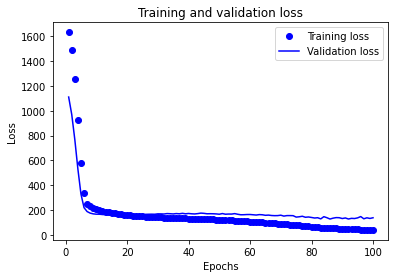

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history
train_loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

# epochs = range(1, len(acc) + 1)
epochs = range(1, 101)

plt.plot(epochs, train_loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

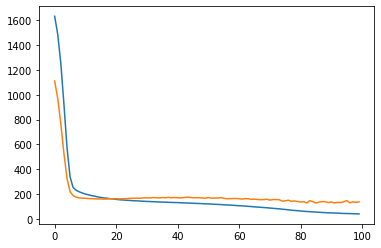

In [ ]:
# same thing, but less verbose:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()


Feel free to vary the following and note what impact each change has on the model's performance:

1. Increase of decreate number of neurons in hidden layers
2. Add more hidden layers
3. Increase number of epochs

## **Final step: using the model to predict strengths for a given concrete type**

In [ ]:
features_norm

,0,1,2,3,4,5,6,7
0,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,0.863154,-1.217670,-0.279733
1,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,1.056164,-1.217670,-0.279733
2,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,3.553066
3,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,5.057677
4,-0.790459,0.678408,-0.847144,0.488793,-1.039143,0.070527,0.647884,4.978487
...,...,...,...,...,...,...,...,...
1025,-0.045645,0.488235,0.564545,-0.092171,0.451410,-1.323005,-0.065893,-0.279733
1026,0.392819,-0.856888,0.960068,0.676200,0.702626,-1.994680,0.496893,-0.279733
1027,-1.270088,0.759579,0.850635,0.521589,-0.017528,-1.036064,0.080107,-0.279733
1028,-1.168610,1.308065,-0.847144,-0.279579,0.853356,0.214641,0.191166,-0.279733


In [ ]:
# let's extract one concrete type from the dataset
concrete_sample = 2
concrete_data = features_norm.iloc[concrete_sample,:]
print(concrete_data)
print(concrete_data.shape)
# and it's real strength
print (target[concrete_sample])

0    0.491425
1    0.795526
2   -0.847144
3    2.175461
4   -1.039143
5   -0.526517
6   -2.240917
7    3.553066
Name: 2, dtype: float64
(8,)
40.27


In [ ]:
# the model.predict method requieres a np.array, so convert the dataframe
# to array:
concrete_data_array = np.array(concrete_data)
print(concrete_data_array)
print(concrete_data_array.shape)
# and reshape it as a row:
concrete_sam = concrete_data_array.reshape(1,8)
print(concrete_sam)
print(concrete_sam.shape)

[ 0.49142531  0.79552649 -0.84714393  2.17546125 -1.03914281 -0.52651741
 -2.24091709  3.55306569]
(8,)
[[ 0.49142531  0.79552649 -0.84714393  2.17546125 -1.03914281 -0.52651741
  -2.24091709  3.55306569]]
(1, 8)


In [ ]:
# predict the strength:
predicted_strength = model.predict(concrete_sam[0:1,:])
print(predicted_strength)

[[47.30165]]


In [ ]:
# however, you don't need to do that if you use the dataframe object to predict.
# Of course, we should have reserved about 15% of the concrete dataset for
# testing, but in this simple example we'll be using the same data just for
# ilustrating the use of the keras methods
predicted_strength = model.predict(features_norm)
print(predicted_strength)

[[66.54771 ]
 [66.7826  ]
 [47.30165 ]
 ...
 [36.749107]
 [37.388832]
 [38.62604 ]]


In [ ]:
# extract a dataframe sample (row):
features_norm.iloc[2:3,:]

,0,1,2,3,4,5,6,7
2,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,3.553066


as expected, prediction for concrete(2) is 44.46209 in both cases. This is near the real strength of 40.27. Thus, our model fits the data correctly

In [ ]:
# another way of doing it (probably the most straigthforward) is:
predicted_strength_concrete2 = model.predict(features_norm.iloc[2:3,:])
print(predicted_strength_concrete2)

[[47.30165]]


In [ ]:
# predict the strength:
predicted_strength_concrete2 = model.predict(features_norm[2:3])
print(predicted_strength_concrete2)

[[47.30165]]


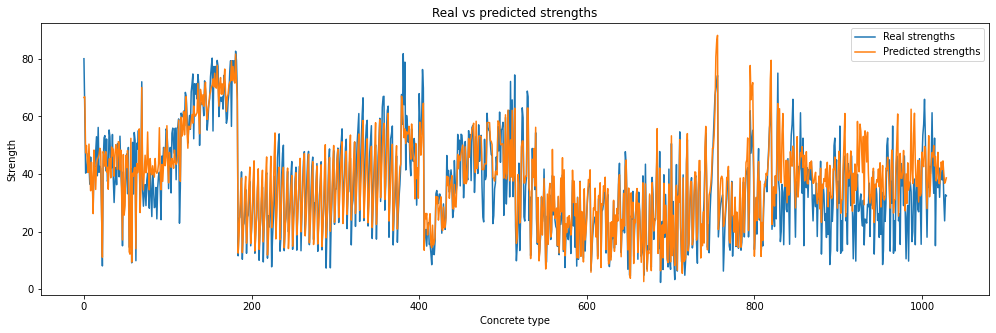

In [ ]:
# plot real concrete strengths vs predicted strengths
from matplotlib import pyplot as plt

plt.figure(figsize=(17,5))
plt.plot(target, label='Real strengths')
plt.plot(predicted_strength, label='Predicted strengths')
plt.title('Real vs predicted strengths')
plt.xlabel('Concrete type')
plt.ylabel('Strength')
plt.legend()
plt.show()

### This notebook is partially inspired by:

The original notebook  created by [Alex Aklson](https://www.linkedin.com/in/aklson/).

This notebook is part of a course on **edX** called *Deep Learning Fundamentals with Keras*. If you accessed this notebook outside the course, you can take this course online by clicking [here](http://cocl.us/DL0101EN_edX_Week3_LAB1).



<hr>

Copyright &copy; 2018 [IBM Developer Skills Network](https://cognitiveclass.ai/?utm_source=bducopyrightlink&utm_medium=dswb&utm_campaign=bdu). This notebook and its source code are released under the terms of the [MIT License](https://bigdatauniversity.com/mit-license/).